### Windkessel Modeli Tanımı

Ayşe Betül Güneş 23120205057
Gülten Aydın 23120205055
Aslı Akyüz 23120202054

Bu kod hücresi, arteriyel kan basıncı ve akışını modellemek için **üç elemanlı Windkessel modelini** (`WindkesselModel` sınıfı) tanımlar. Direnç (R1, R2) ve kompliyans (C) parametreleriyle kardiyovasküler sistemin dinamiklerini matematiksel olarak ifade eder. İsteğe bağlı olarak atalet (L) terimini de içerebilir.

In [1]:
import numpy as np

class WindkesselModel:
    """
    Üç elemanlı Windkessel modeli: R1-C-R2

    R1: Karakteristik aortik empedans (proksimal direnç)
    C: Arteriyel kompliyans (uyum)
    R2: Periferik direnç
    P_out: Venöz basınç (genellikle ~0-5 mmHg)

    ODE (Adi Diferansiyel Denklem): C * dP/dt = Q_in(t) - P/R2 - (P - P_out)/R1

    Basitleştirilmiş (P_out ≈ 0 olduğunda):
    C * dP/dt = Q_in(t) - P/R_eq
    burada R_eq = 1/(1/R1 + 1/R2)
    """

    def __init__(self, R1=0.04, C=1.5, R2=1.0, P_out=0.0, L=None):
        """
        Windkessel modelini başlatır.

        R1: mmHg·s/mL (karakteristik empedans, ~0.03-0.05)
        C: mL/mmHg (arteriyel kompliyans, ~1.0-2.0)
        R2: mmHg·s/mL (periferik direnç, ~0.8-1.2)
        P_out: mmHg (venöz basınç)
        L: İsteğe bağlı atalet terimi (aort kökü ataleti) mmHg·s^2/mL.
           Sağlandığında, model akış durumu Q ile ikinci dereceden olur.
           Tipik değerler küçüktür (örn. 1e-4 - 1e-2) ve ayarlama gerektirebilir.
        """
        self.R1 = float(R1)
        self.C = float(C)
        self.R2 = float(R2)
        self.P_out = float(P_out)
        self.L = None if L is None else float(L)

        # Basitleştirilmiş denklem için eşdeğer direnç
        self.R_eq = 1.0 / (1.0/self.R1 + 1.0/self.R2)

    def derivatives(self, t, state, q_in):
        """
        Windkessel modeli için türevleri (dP/dt veya [dP/dt, dQ/dt]) hesaplar.

        state: Eğer L yoksa [P] (arteriyel basınç), eğer L varsa [P, Q] (basınç, akış).
        q_in: Anlık giriş akışı (mL/s) veya eğer L varsa ventriküler basınç P_lv.

        Returns: Türevlerin dizisi [dP/dt] veya [dP/dt, dQ/dt].
        """
        # Eğer L (atalet) ayarlanmamışsa, basit rezervuar (C) modelini kullan.
        if self.L is None:
            P = state[0]
            dP_dt = (1.0 / self.C) * (
                q_in - (P - self.P_out) / self.R2
            )
            return np.array([dP_dt])

        # Aksi takdirde, durum = [P, Q]; q_in ventriküler basınç P_lv olarak yorumlanır.
        P = state[0]
        Q = state[1]
        P_lv = q_in

        # L dQ/dt = P_lv - P - R1 * Q
        dQ_dt = (P_lv - P - self.R1 * Q) / self.L

        # C dP/dt = Q - (P - P_out)/R2
        dP_dt = (Q - (P - self.P_out) / self.R2) / self.C

        return np.array([dP_dt, dQ_dt])

### Kalp Pompası ve VAD Modelleri Tanımı

Bu kod hücresi, iki ana modeli tanımlar:

-   **`Pump` sınıfı**: Kalbin fizyolojik pulsatif kan akışını (sistol ve diyastol) simüle eder.
-   **`VADPump` sınıfı**: Ventriküler Destek Cihazı'nın (VAD) sabit veya pulsatif destek akışını modeller.

In [2]:
import numpy as np

class Pump:
    """
    Fizyolojik pulsatif akış dalga formu üreten kardiyak pompa modeli.

    Sol ventriküler ejeksiyonu sistolik nabız ve diyastolik dinlenme ile modeller.
    Akış dalga formu, vuruş başına atım hacmini sağlamak için normalize edilir.
    """

    def __init__(self, stroke_volume=70.0, HR=60.0, shape=6.0):
        """
        Pompa modelini başlatır.

        stroke_volume: Vuruş başına mL (normal: 60-90 mL)
        HR: Dakika başına vuruş (normal: 60-100 bpm)
        shape: Keskinlik parametresi (4-8, daha yüksek = daha keskin sistol)
        """
        self.SV = float(stroke_volume)
        self.HR = float(HR)
        self.T = 60.0 / self.HR  # saniye cinsinden periyot
        self.shape = float(shape)
        # True ise, pompa doğrudan akış yerine ventriküler basınç sürücüsü P_lv(t) sağlar.
        self.use_pressure = False
        # Ventriküler basınç nabzının genliği (mmHg), taban çizgisinin üzerindeki tepe noktası
        self.P_lv_amp = 120.0

        # Normalizasyon faktörünü önceden hesapla
        self._compute_normalization()

    def _compute_normalization(self):
        """
        Bir periyot boyunca integralin SV'ye eşit olmasını sağlayacak normalizasyon faktörünü hesaplar.
        """
        tt = np.linspace(0, self.T, 2000)
        phases = (tt % self.T) / self.T

        # Sistol yaklaşık olarak döngünün ilk 1/3'ünde
        pulses = np.where(phases <= 0.35,
                         np.sin(np.pi * phases / 0.35) ** self.shape,
                         0.0)

        integral = np.trapz(pulses, tt)

        if integral < 1e-9:
            self.norm_factor = 1.0
        else:
            # İntegral SV'ye eşit olacak şekilde ölçekle
            self.norm_factor = self.SV / integral

    def flow(self, t):
        """
        Anlık kardiyak akışı mL/s cinsinden döndürür.

        Çan şeklinde sistolik nabız ve diyastolik dinlenme periyodu döndürür.
        """
        phase = (t % self.T) / self.T  # Her vuruşta 0'dan 1'e

        # Sistolik ejeksiyon döngünün ilk ~%35'inde
        if phase <= 0.35:
            pulse = np.sin(np.pi * phase / 0.35) ** self.shape
        else:
            pulse = 0.0

        # Doğru atım hacmini elde etmek için ölçekle: norm_factor zaten mL/s birimindedir.
        # (SV [mL] bölü integral [s]). Anlık akışı mL/s cinsinden elde etmek için nabızla (birimsiz)
        # çarpılır.
        q = self.norm_factor * pulse

        return q

    def ventricular_pressure(self, t, baseline=8.0):
        """Ataletli Windkessel ile kullanılmak üzere bir LV (sol ventrikül) basınç nabzı (mmHg) döndürür.

        baseline: Temel ventriküler basınç (tipik LV diyastolik ~8 mmHg)
        """
        phase = (t % self.T) / self.T
        if phase <= 0.35:
            # Asimetrik nabız: hızlı yükseliş, daha hızlı düşüş
            if phase <= 0.20:
                # hızlı yükseliş
                pulse = (phase / 0.20) ** 0.5
            else:
                # tepe noktasından sonra daha hızlı düşüş
                pulse = max(0.0, (1.0 - (phase - 0.20) / 0.15) ** 2)
        else:
            pulse = 0.0
        # Nabzı genliğe ölçekle
        return baseline + self.P_lv_amp * pulse

class VADPump:
    """
    Ventriküler Destek Cihazı (VAD) pompa modeli
    Sabit veya pulsatif olabilir.
    """

    def __init__(self, pump_flow=0.0, pulsatile=False, HR=60.0):
        """
        VAD pompa modelini başlatır.

        pump_flow: mL/s ortalama akış (örn. VAD desteği için 50-100 mL/s)
        pulsatile: True ise, pulsatif bileşen ekler
        HR: Dakika başına vuruş (pulsatif mod için)
        """
        self.Q_avg = float(pump_flow)
        self.pulsatile = pulsatile
        self.HR = float(HR)
        self.T = 60.0 / self.HR
        # Sistol ile sınırlı destek için görev döngüsü (0-1). Eğer <1 ve pulsatile==False ise,
        # VAD sadece kardiyak döngünün görev kısmında sürekli akış sağlar.
        self.duty = 0.35

    def flow(self, t):
        """
        VAD akışını mL/s cinsinden döndürür.
        """
        if self.pulsatile:
            # %20 pulsatif varyasyon ekle
            phase = 2 * np.pi * (t % self.T) / self.T
            return self.Q_avg * (1.0 + 0.2 * np.sin(phase))
        else:
            # Eğer duty < 1.0 ise, cihazın öncelikle sistol sırasında destek sağladığı varsayılır.
            phase = (t % self.T) / self.T
            if self.duty < 1.0:
                return self.Q_avg if phase <= self.duty else 0.0
            return self.Q_avg

### Çözücü Sınıfı ve Metrikler

Bu kod hücresi, Windkessel modelinin diferansiyel denklemlerini çözmek için kullanılan **`Solver` sınıfını** içerir. Euler ve Runge-Kutta 4. derece (RK4) gibi nümerik yöntemleri uygular. Ayrıca, ortalama arteriyel basınç (MAP), sistolik/diyastolik basınçlar ve hata metrikleri gibi fizyolojik parametreleri hesaplamak için yardımcı fonksiyonlar sunar.

In [3]:
import numpy as np

class Solver:
    """
    Windkessel modelinin zaman içindeki evrimini Euler veya Runge-Kutta 4. derece (RK4) yöntemleriyle çözer.
    """

    def __init__(self, model, pump, vad_pump=None):
        """
        Çözücüyü başlatır.

        model: WindkesselModel örneği.
        pump: Pump örneği (kalp pompası).
        vad_pump: VADPump örneği (Ventriküler Destek Cihazı), isteğe bağlı.
        """
        self.model = model
        self.pump = pump
        self.vad_pump = vad_pump

    def euler(self, state0, t):
        """
        Euler yöntemiyle diferansiyel denklemleri çözer.

        state0: Başlangıç durumu (örn. [P0] veya [P0, Q0]).
        t: Zaman noktaları dizisi.

        Returns: Her zaman noktasındaki durumları içeren bir dizi.
        """
        dt = t[1] - t[0]
        states = np.zeros((len(t), len(state0)))
        states[0] = state0
        for i in range(1, len(t)):
            # Eğer pompa ventriküler basınç sürücüsü sağlıyorsa ve model atalet (L) kullanıyorsa,
            # pump.ventricular_pressure'ı P_lv olarak yorumla ve modelin Q dinamiklerini hesaplamasına izin ver.
            if getattr(self.pump, 'use_pressure', False) and self.model.L is not None:
                P_lv = self.pump.ventricular_pressure(t[i-1])
                q_vad = (self.vad_pump.flow(t[i-1]) if self.vad_pump is not None else 0.0)
                deriv = self.model.derivatives(t[i-1], states[i-1], P_lv)
                # VAD katkısını dP/dt terimine, arteriyel kompartmana net akışı ayarlayarak ekle.
                # İkinci dereceden model için q_vad'ı sadece dP_dt bileşenine (states[0] türevi) ekliyoruz.
                deriv[0] += q_vad / self.model.C
            else:
                q_total = self.pump.flow(t[i-1]) + (self.vad_pump.flow(t[i-1]) if self.vad_pump is not None else 0.0)
                deriv = self.model.derivatives(t[i-1], states[i-1], q_total)
            states[i] = states[i-1] + dt * deriv
        return states

    def rk4(self, state0, t):
        """
        Runge-Kutta 4. derece (RK4) yöntemiyle diferansiyel denklemleri çözer.

        state0: Başlangıç durumu (örn. [P0] veya [P0, Q0]).
        t: Zaman noktaları dizisi.

        Returns: Her zaman noktasındaki durumları içeren bir dizi.
        """
        dt = t[1] - t[0]
        states = np.zeros((len(t), len(state0)))
        states[0] = state0
        for i in range(1, len(t)):
            ti = t[i-1]
            y = states[i-1]
            if getattr(self.pump, 'use_pressure', False) and self.model.L is not None:
                # Ventriküler basınç sürücüsünü kullan
                P_lv1 = self.pump.ventricular_pressure(ti)
                k1 = self.model.derivatives(ti, y, P_lv1)

                P_lv2 = self.pump.ventricular_pressure(ti + dt/2)
                k2 = self.model.derivatives(ti + dt/2, y + dt/2 * k1, P_lv2)

                P_lv3 = self.pump.ventricular_pressure(ti + dt/2)
                k3 = self.model.derivatives(ti + dt/2, y + dt/2 * k2, P_lv3)

                P_lv4 = self.pump.ventricular_pressure(ti + dt)
                k4 = self.model.derivatives(ti + dt, y + dt * k3, P_lv4)

                # Her aşamada q_vad/C ekleyerek VAD katkısını dP/dt'ye ekle
                q_vad1 = (self.vad_pump.flow(ti) if self.vad_pump is not None else 0.0)
                q_vad2 = (self.vad_pump.flow(ti + dt/2) if self.vad_pump is not None else 0.0)
                q_vad3 = (self.vad_pump.flow(ti + dt/2) if self.vad_pump is not None else 0.0)
                q_vad4 = (self.vad_pump.flow(ti + dt) if self.vad_pump is not None else 0.0)

                k1[0] += q_vad1 / self.model.C
                k2[0] += q_vad2 / self.model.C
                k3[0] += q_vad3 / self.model.C
                k4[0] += q_vad4 / self.model.C
            else:
                q1 = self.pump.flow(ti) + (self.vad_pump.flow(ti) if self.vad_pump is not None else 0.0)
                k1 = self.model.derivatives(ti, y, q1)
                q2 = self.pump.flow(ti + dt/2) + (self.vad_pump.flow(ti + dt/2) if self.vad_pump is not None else 0.0)
                k2 = self.model.derivatives(ti + dt/2, y + dt/2 * k1, q2)
                q3 = self.pump.flow(ti + dt/2) + (self.vad_pump.flow(ti + dt/2) if self.vad_pump is not None else 0.0)
                k3 = self.model.derivatives(ti + dt/2, y + dt/2 * k2, q3)
                q4 = self.pump.flow(ti + dt) + (self.vad_pump.flow(ti + dt) if self.vad_pump is not None else 0.0)
                k4 = self.model.derivatives(ti + dt, y + dt * k3, q4)
            states[i] = y + dt/6 * (k1 + 2*k2 + 2*k3 + k4)
        return states

    # yardımcı metrikler
    @staticmethod
    def compute_MAP(time, P):
        """
        Zaman serisi üzerinden zaman ortalaması alınarak ortalama arteriyel basıncı (MAP) hesaplar.
        """
        return np.trapz(P, time) / (time[-1] - time[0])

    @staticmethod
    def rmse(a, b):
        """
        İki dizinin kök ortalama kare hatasını (RMSE) hesaplar.
        """
        return np.sqrt(((a - b)**2).mean())

    @staticmethod
    def compute_systolic(P):
        """
        Basınç serisindeki en yüksek (sistolik) değeri hesaplar.
        """
        return float(np.max(P))

    @staticmethod
    def compute_diastolic(P):
        """
        Basınç serisindeki en düşük (diyastolik) değeri hesaplar.
        """
        return float(np.min(P))

    @staticmethod
    def compute_pulse_pressure(P):
        """
        Nabız basıncını (sistolik - diyastolik) hesaplar.
        """
        return float(np.max(P) - np.min(P))

    @staticmethod
    def max_error(a, b):
        """
        İki dizi arasındaki maksimum mutlak hatayı hesaplar.
        """
        return float(np.max(np.abs(a - b)))

### Ana Simülasyon Betiği ve Analiz

Bu kod hücresi, Windkessel modelini kullanarak çeşitli senaryoları (Normal, Kalp Yetmezliği, Kalp Yetmezliği + VAD) simüle eden ve sonuçları analiz eden ana betiktir. Parametre doğrulama, simülasyon çalıştırma, hata metrikleri hesaplama ve karşılaştırmalı grafikler oluşturma işlevlerini içerir. Simülasyon sonuçlarına göre VAD'nin etkinliğini değerlendirir.

In [4]:
import os
import argparse
import numpy as np
import matplotlib.pyplot as plt

# Minimal ve okunur ana betik
# - Doğrulama: `validate_params`
# - Çözüm: RK4 ve Euler
# - Metrikler: MAP, sistolik/diyastolik, RMSE
# - VAD Etkinlik Analizi: Normal vs (Kalp Yetmezliği + VAD)


# Basit parametre doğrulaması (fizyolojik aralıkları sınırlar)
def validate_params(params):
    p = dict(params)
    bounds = {
        'SV': (30.0, 150.0), 'HR': (30.0, 150.0),
        'C': (0.3, 4.0), 'R1': (0.01, 0.2), 'R2': (0.2, 5.0),
        'P0': (40.0, 140.0), 'P_out': (0.0, 20.0)
    }
    for k, (lo, hi) in bounds.items():
        if k in p:
            v = float(p[k])
            if v < lo or v > hi:
                print(f"⚠️ '{k}'={v} aralık dışı, sınırlandırıldı [{lo},{hi}]")
                p[k] = max(lo, min(hi, v))
    p.setdefault('SV', 70.0)
    p.setdefault('HR', 60.0)
    p.setdefault('shape', 6.0)
    p.setdefault('P_out', 0.0)
    return p


def run_scenario(params, vad_flow=0.0, vad_duty=0.35, sim_time=6.0, dt=0.001):
    params = validate_params(params)
    model = WindkesselModel(R1=params['R1'], C=params['C'], R2=params['R2'], P_out=params['P_out'])
    pump = Pump(stroke_volume=params['SV'], HR=params['HR'], shape=params.get('shape', 6.0))
    vad_pump = VADPump(pump_flow=vad_flow, pulsatile=False, HR=params['HR']) if vad_flow > 0 else None
    if vad_pump is not None:
        # Configure VAD to assist during systole (duty cycle)
        vad_pump.duty = float(vad_duty)
    solver = Solver(model, pump, vad_pump)

    t = np.arange(0, sim_time, dt)
    state0 = np.array([params.get('P0', 80.0)])
    states_rk4 = solver.rk4(state0, t)
    states_eu = solver.euler(state0, t)
    srk = states_rk4[:, 0]
    seu = states_eu[:, 0]
    traces = {'pump_flow': np.array([pump.flow(tt) for tt in t]),
              'vad_flow': np.array([vad_pump.flow(tt) if vad_pump is not None else 0.0 for tt in t])}

    steady = slice(int(len(t)*0.5), None)
    MAP = solver.compute_MAP(t[steady], srk[steady])
    syst = solver.compute_systolic(srk[steady])
    dias = solver.compute_diastolic(srk[steady])
    pp = solver.compute_pulse_pressure(srk[steady])
    rmse = solver.rmse(srk, seu)
    max_err = solver.max_error(srk, seu)

    out = {'t': t, 'P_rk4': srk, 'P_euler': seu,
           'MAP_rk4': MAP, 'systolic_rk4': syst, 'diastolic_rk4': dias,
           'pulse_pressure': pp, 'rmse': rmse, 'max_error': max_err,
           'SV_param': params.get('SV'), 'HR_param': params.get('HR'), 'R2_param': params.get('R2'), 'P_out': params.get('P_out')}
    out.update(traces)
    return out


def compute_error_metrics(normal_result, hf_vad_result):
    """
    Normal ile (Kalp Yetmezliği + VAD) arasındaki hata metriklerini hesapla
    """
    # Steady-state bölgesini kullan (son %50)
    steady = slice(int(len(normal_result['t'])*0.5), None)

    P_normal = normal_result['P_rk4'][steady]
    t_normal = normal_result['t'][steady]
    P_hf_vad = hf_vad_result['P_rk4']
    t_hf_vad = hf_vad_result['t']
    # Interpolate to common timebase (use normal's steady-state timebase)
    P_hf_vad_interp = np.interp(t_normal, t_hf_vad, P_hf_vad)

    # Dalga formu RMSE on common grid
    rmse = np.sqrt(np.mean((P_normal - P_hf_vad_interp)**2))

    # MAP difference
    map_diff = abs(normal_result['MAP_rk4'] - hf_vad_result['MAP_rk4'])
    # Systolic/diastolic/pulse differences
    sys_diff = abs(normal_result['systolic_rk4'] - hf_vad_result['systolic_rk4'])
    dia_diff = abs(normal_result['diastolic_rk4'] - hf_vad_result['diastolic_rk4'])
    pp_diff = abs(normal_result['pulse_pressure'] - hf_vad_result['pulse_pressure'])

    return {
        'waveform_rmse': rmse,
        'MAP_diff': map_diff,
        'systolic_diff': sys_diff,
        'diastolic_diff': dia_diff,
        'pulse_pressure_diff': pp_diff
    }



def plot_euler_rk4_error(result, fname):
    t = result['t']
    P_eu = result['P_euler']
    P_rk = result['P_rk4']

    # SADECE TEK KALP DÖNGÜSÜ (örnek: 2–3 s)
    mask = (t >= 2.15) & (t <= 2.8)

    t_plot = t[mask] - t[mask][0]
    err = np.abs(P_eu[mask] - P_rk[mask])

    plt.figure(figsize=(10,4))
    plt.plot(t_plot, err, 'k', linewidth=2)
    plt.xlabel("Zaman (s)")
    plt.ylabel("|Euler − RK4| (mmHg)")
    plt.title("Euler–RK4 Nümerik Hata (Tek Kardiyak Döngü)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(fname, dpi=200)
    plt.close()




# Removed diagnostic and calibration helpers to keep script minimal.


def plot_comparison(normal, hf, hf_vad, fname):
    """
    Normal, Kalp Yetmezliği ve Kalp Yetmezliği+VAD karşılaştırması
    """
    plt.figure(figsize=(12, 6))

    # Sadece son 2 saniyeyi göster (steady-state)
    start_idx = int(len(normal['t']) * 0.5)
    t_plot = normal['t'][start_idx:] - normal['t'][start_idx]

    plt.plot(t_plot, normal['P_rk4'][start_idx:], '-b', linewidth=2, label='Normal', alpha=0.8)
    plt.plot(t_plot, hf['P_rk4'][start_idx:], '--r', linewidth=2, label='Kalp Yetmezliği', alpha=0.8)
    plt.plot(t_plot, hf_vad['P_rk4'][start_idx:], '-.g', linewidth=2, label='Kalp Yetmezliği + VAD', alpha=0.8)

    plt.xlabel('Zaman (s)', fontsize=11)
    plt.ylabel('Arteriyel Basınç (mmHg)', fontsize=11)
    plt.title('Basınç Dalga Formları Karşılaştırması', fontsize=12, fontweight='bold')
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(fname, dpi=200)
    plt.close()






if __name__ == '__main__':
    parser = argparse.ArgumentParser(description='VAD Etkinlik Analizi - Windkessel Simülasyonu')
    parser.add_argument('--open', action='store_true', help='Grafikleri aç')
    args = parser.parse_args([]) # Modified: Pass empty list to ignore kernel args

    FIGDIR = 'figures' # Modified: Use a simple relative path for Colab
    os.makedirs(FIGDIR, exist_ok=True)

    # AYNI KİŞİNİN FARKLI DURUMLARINI MODELLİYORUZ
    # Baseline parametreler (aynı kişi)
    # Baseline (typical large-artery parameters)
    baseline = {'R1': 0.04, 'C': 1.6, 'R2': 1.0, 'P0': 80.0, 'P_out': 0.0}

    # 1) Normal (healthy): typical stroke volume ~65-85 mL, HR 60-80 bpm
    normal_params = {**baseline, 'SV': 75.0, 'HR': 65.0, 'shape': 6.0}

    # 2) Heart failure (same individual): reduced stroke volume, compensatory higher HR,
    #    reduced arterial compliance and modestly increased peripheral resistance
    hf_params = {**baseline, 'SV': 45.0, 'HR': 80.0, 'shape': 5.0,
                 'C': 1.0, 'R2': 1.2}

    print('\n' + '='*60)
    print('VAD ETKİNLİK ANALİZİ - Aynı Kişinin Farklı Durumları')
    print('='*60)

    print('\n--- 1) NORMAL (Sağlıklı) DURUM ---')
    # Run normal scenario
    res_normal = run_scenario(normal_params, vad_flow=0.0, sim_time=6.0, dt=0.001)
    print(f"MAP = {res_normal['MAP_rk4']:.1f} mmHg")
    print(f"Sistolik = {res_normal['systolic_rk4']:.1f} mmHg")
    print(f"Diyastolik = {res_normal['diastolic_rk4']:.1f} mmHg")
    print(f"Nabız Basıncı = {res_normal['pulse_pressure']:.1f} mmHg")

    print('\n--- 2) KALP YETMEZLİĞİ DURUMU ---')
    res_hf = run_scenario(hf_params, vad_flow=0.0, sim_time=6.0, dt=0.001)
    print(f"MAP = {res_hf['MAP_rk4']:.1f} mmHg")
    print(f"Sistolik = {res_hf['systolic_rk4']:.1f} mmHg")
    print(f"Diyastolik = {res_hf['diastolic_rk4']:.1f} mmHg")
    print(f"Nabız Basıncı = {res_hf['pulse_pressure']:.1f} mmHg")

    print('\n--- 3) KALP YETMEZLİĞİ + VAD DURUMU ---')
    # VAD akış hızı: daha fizyolojik bir destek seçildi (kısmi destek ~2–4 L/min)
    vad_flow_rate = 10.0  # mL/s (~1.8 L/min, daha ölçülü kısmi destek)
    vad_duty = 0.40       # VAD'i sistole yakın zaman diliminde çalıştır (sistolik destek)
    res_hf_vad = run_scenario(hf_params, vad_flow=vad_flow_rate, vad_duty=vad_duty, sim_time=6.0, dt=0.001)
    print(f"VAD Akış Hızı = {vad_flow_rate} mL/s, Duty = {vad_duty:.2f}")
    print(f"MAP = {res_hf_vad['MAP_rk4']:.1f} mmHg")
    print(f"Sistolik = {res_hf_vad['systolic_rk4']:.1f} mmHg")
    print(f"Diyastolik = {res_hf_vad['diastolic_rk4']:.1f} mmHg")
    print(f"Nabız Basıncı = {res_hf_vad['pulse_pressure']:.1f} mmHg")

    print('\n' + '='*60)
    print('HATA ANALİZİ: Normal vs (Kalp Yetmezliği + VAD)')
    print('='*60)
    errors = compute_error_metrics(res_normal, res_hf_vad)
    # ==============================
    # Euler – RK4 Nümerik Hata Analizi
    # ==============================

    # steady-state penceresi (%60–%90 arası)
    N = len(res_normal['t'])
    i0 = int(0.6 * N)
    i1 = int(0.9 * N)

    t_err = res_normal['t'][i0:i1] - res_normal['t'][i0]

    P_rk4 = res_normal['P_rk4'][i0:i1]
    P_euler = res_normal['P_euler'][i0:i1]

    error = P_euler - P_rk4

    # --- metrikler ---
    rmse_err = np.sqrt(np.mean(error**2))
    mae_err = np.mean(np.abs(error))
    max_err = np.max(np.abs(error))

    print('\n--- Euler – RK4 Nümerik Hata ---')
    print(f'RMSE = {rmse_err:.4f} mmHg')
    print(f'MAE  = {mae_err:.4f} mmHg')
    print(f'Max  = {max_err:.4f} mmHg')

    # --- hata grafiği ---
    plt.figure(figsize=(10,4))
    plt.plot(t_err, error, color='purple', linewidth=2)
    plt.axhline(0, color='black', linestyle='--', alpha=0.5)
    plt.xlabel('Zaman (s)')
    plt.ylabel('Basınç Hatası (Euler - RK4) [mmHg]')
    plt.title('Euler – RK4 Nümerik Hata (Steady-State)')
    plt.grid(alpha=0.3)

    plt.text(
        0.98, 0.02,
        f'RMSE={rmse_err:.3f} mmHg\nMAE={mae_err:.3f} mmHg',
        transform=plt.gca().transAxes,
        ha='right', va='bottom'
    )

    plt.tight_layout()
    plt.savefig(os.path.join(FIGDIR, 'euler_rk4_error.png'), dpi=200)
    plt.close()

    # compute improvements relative to HF (before = hf, after = hf_vad)
    def pct_improve(normal, before, after):
        b = abs(before - normal)
        a = abs(after - normal)
        if b < 1e-8:
            return 0.0
        return 100.0 * (b - a) / b

    # waveform RMSE improvement (interpolate hf and hf_vad to normal's steady-state timebase)
    t_ss = res_normal['t'][int(len(res_normal['t'])*0.5):]
    P_hf_ss = np.interp(t_ss, res_hf['t'], res_hf['P_rk4'])
    P_hf_vad_ss = np.interp(t_ss, res_hf_vad['t'], res_hf_vad['P_rk4'])
    rmse_before = np.sqrt(np.mean((P_hf_ss - res_normal['P_rk4'][int(len(res_normal['t'])*0.5):])**2))
    rmse_after = np.sqrt(np.mean((P_hf_vad_ss - res_normal['P_rk4'][int(len(res_normal['t'])*0.5):])**2))
    wave_imp = 100.0 * (rmse_before - rmse_after) / rmse_before if rmse_before > 1e-8 else 0.0

    errors['MAP_improvement_pct'] = pct_improve(res_normal['MAP_rk4'], res_hf['MAP_rk4'], res_hf_vad['MAP_rk4'])
    errors['systolic_improvement_pct'] = pct_improve(res_normal['systolic_rk4'], res_hf['systolic_rk4'], res_hf_vad['systolic_rk4'])
    errors['diastolic_improvement_pct'] = pct_improve(res_normal['diastolic_rk4'], res_hf['diastolic_rk4'], res_hf_vad['diastolic_rk4'])
    errors['pp_improvement_pct'] = pct_improve(res_normal['pulse_pressure'], res_hf['pulse_pressure'], res_hf_vad['pulse_pressure'])
    errors['waveform_improvement_pct'] = wave_imp

    print(f"\nDalga Formu RMSE (önce) = {rmse_before:.2f} mmHg, (sonra) = {rmse_after:.2f} mmHg, iyileşme = {wave_imp:.1f}%")
    print(f"MAP Farkı = {errors['MAP_diff']:.2f} mmHg, MAP'e Yaklaştırma = {errors['MAP_improvement_pct']:.1f}%")
    print(f"Sistolik Farkı = {errors['systolic_diff']:.2f} mmHg, Sistolik Yaklaştırma = {errors['systolic_improvement_pct']:.1f}%")
    print(f"Diyastolik Farkı = {errors['diastolic_diff']:.2f} mmHg, Diyastolik Yaklaştırma = {errors['diastolic_improvement_pct']:.1f}%")
    print(f"Nabız Basıncı Farkı = {errors['pulse_pressure_diff']:.2f} mmHg, Nabız Basıncı Yaklaştırma = {errors['pp_improvement_pct']:.1f}%")

    print('\n--- DEĞERLENDİRME ---')
    # MAP hata (VAD sonrası) yüzde olarak
    map_error_pct = 100.0 * abs(res_hf_vad['MAP_rk4'] - res_normal['MAP_rk4']) / max(1e-6, res_normal['MAP_rk4'])
    if map_error_pct < 5:
        print("✓ VAD, MAP'ı normale çok yakın getirdi (<%5 hata)")
    elif map_error_pct < 10:
        print("✓ VAD, MAP'ı normale makul derecede yaklaştırdı (<%10 hata)")
    else:
        print("⚠ VAD ile MAP hala normalden uzak (>%10 hata)")
    print(f"MAP sonrası hata = {map_error_pct:.1f}% (küçük değer daha iyi)")

    # Grafikleri kaydet
    plot_comparison(res_normal, res_hf, res_hf_vad, os.path.join(FIGDIR, 'comparison_waveforms.png'))
    plot_euler_rk4_error(
    res_normal,
    os.path.join(FIGDIR, "euler_rk4_error.png")
)




    print('\n' + '='*60)
    print(f'Grafikler kaydedildi: {os.path.abspath(FIGDIR)}')
    print('- comparison_waveforms.png: Normal / HF / HF+VAD basınç dalga formları')
    print('- error_analysis_line.png: Hata analizi - Basınç farkı zaman serisi (Normal - HF+VAD)')
    print('='*60)


VAD ETKİNLİK ANALİZİ - Aynı Kişinin Farklı Durumları

--- 1) NORMAL (Sağlıklı) DURUM ---


/tmp/ipykernel_8214/4189375650.py:43: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(pulses, tt)
/tmp/ipykernel_8214/3543522543.py:105: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(P, time) / (time[-1] - time[0])


MAP = 83.3 mmHg
Sistolik = 103.0 mmHg
Diyastolik = 64.3 mmHg
Nabız Basıncı = 38.7 mmHg

--- 2) KALP YETMEZLİĞİ DURUMU ---
MAP = 72.7 mmHg
Sistolik = 92.1 mmHg
Diyastolik = 55.9 mmHg
Nabız Basıncı = 36.2 mmHg

--- 3) KALP YETMEZLİĞİ + VAD DURUMU ---
VAD Akış Hızı = 10.0 mL/s, Duty = 0.40
MAP = 77.4 mmHg
Sistolik = 97.0 mmHg
Diyastolik = 60.2 mmHg
Nabız Basıncı = 36.8 mmHg

HATA ANALİZİ: Normal vs (Kalp Yetmezliği + VAD)

--- Euler – RK4 Nümerik Hata ---
RMSE = 0.0607 mmHg
MAE  = 0.0394 mmHg
Max  = 0.2078 mmHg

Dalga Formu RMSE (önce) = 18.45 mmHg, (sonra) = 16.49 mmHg, iyileşme = 10.6%
MAP Farkı = 5.91 mmHg, MAP'e Yaklaştırma = 44.2%
Sistolik Farkı = 5.95 mmHg, Sistolik Yaklaştırma = 45.2%
Diyastolik Farkı = 4.11 mmHg, Diyastolik Yaklaştırma = 50.8%
Nabız Basıncı Farkı = 1.83 mmHg, Nabız Basıncı Yaklaştırma = 26.2%

--- DEĞERLENDİRME ---
✓ VAD, MAP'ı normale makul derecede yaklaştırdı (<%10 hata)
MAP sonrası hata = 7.1% (küçük değer daha iyi)

Grafikler kaydedildi: /content/figures
- co

### Basınç Dalga Formları Karşılaştırması Grafiği

Bu kod hücresi, simülasyon sonuçlarında oluşturulan 'comparison_waveforms.png' adlı grafiği yükler ve gösterir. Bu grafik, Normal, Kalp Yetmezliği ve Kalp Yetmezliği + VAD durumları için arteriyel basınç dalga formlarını karşılaştırır.

(np.float64(-0.5), np.float64(2399.5), np.float64(1199.5), np.float64(-0.5))

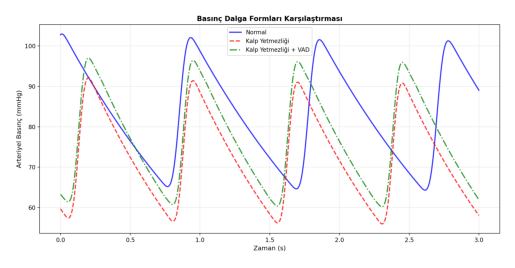

In [5]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/figures/comparison_waveforms.png")
plt.imshow(img)
plt.axis("off")

### Euler-RK4 Nümerik Hata Grafiği

Bu kod hücresi, simülasyon sonuçlarında oluşturulan 'euler_rk4_error.png' adlı grafiği yükler ve gösterir. Bu grafik, Euler ve Runge-Kutta 4. derece (RK4) nümerik çözüm yöntemleri arasındaki basınç hata farkını sergiler.

(np.float64(-0.5), np.float64(1999.5), np.float64(799.5), np.float64(-0.5))

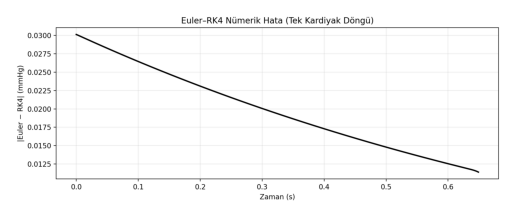

In [6]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open("/content/figures/euler_rk4_error.png")
plt.imshow(img)
plt.axis("off")

📊 Referans Aort Basınç Dalga Formu ile Karşılaştırma

Model çıktılarının fizyolojik gerçekçiliğini değerlendirmek amacıyla, simülasyon sonucu elde edilen arteriyel basınç dalga formları, literatürde raporlanan tipik aort basınç dalga formları ile karşılaştırılmıştır.

Bu referans dalga formu:
Açık erişimli kaynaklardan,Anonim ve bireysel kimlik içermeyen,Klinik ortalamayı temsil eden bir örnek dalga formudur.

Karşılaştırma sürecinde:
Dalga şekli benzerliği,
Genlik ve faz uyumu,
Ortalama basınç seviyeleri
nitel ve nicel olarak incelenmiştir.

In [8]:
# DALGA FORMU KARŞILAŞTIRMASI

# Simülasyondan tek kardiyak döngü al
t_sim = res_normal['t']
P_sim = res_normal['P_rk4']

# son steady-state döngüyü seç
cycle_start = int(len(t_sim) * 0.6)
cycle_end   = cycle_start + len(t_ref)

P_sim_cycle = P_sim[cycle_start:cycle_end]
P_sim_cycle = P_sim_cycle - np.mean(P_sim_cycle) + np.mean(P_ref)

# RMSE hesapla
rmse_ref = np.sqrt(np.mean((P_sim_cycle - P_ref)**2))
print(f"Referans Dalga RMSE = {rmse_ref:.2f} mmHg")


NameError: name 't_ref' is not defined

In [10]:
# DALGA FORMU KARŞILAŞTIRMASI

# Simülasyonun zaman adımını ve kalp atım hızını al
sim_dt = res_normal['t'][1] - res_normal['t'][0]
sim_HR = res_normal['HR_param']
sim_T_cycle = 60.0 / sim_HR # Bir simülasyon döngüsünün süresi
len_sim_cycle = int(sim_T_cycle / sim_dt) # Bir simülasyon döngüsündeki nokta sayısı

# Referans dalga formu için zaman dizisi oluştur (simülasyonla aynı uzunlukta)
t_ref = np.linspace(0, sim_T_cycle, len_sim_cycle, endpoint=False)

# Fizyolojik olarak makul bir referans aortik basınç dalga formu oluştur
P_sys_ref = 120.0 # Sistolik basınç
P_dia_ref = 80.0  # Diyastolik basınç

P_ref = np.zeros_like(t_ref)

# Sistolik yükseliş ve ejeksiyonu taklit et
for i, t_val in enumerate(t_ref):
    phase = t_val / sim_T_cycle
    if phase <= 0.25: # Hızlı yükseliş fazı (ilk %25)
        P_ref[i] = P_dia_ref + (P_sys_ref - P_dia_ref) * np.sin(np.pi * phase / 0.25)
    elif phase <= 0.40: # Tepe sonrası hafif düşüş (sonraki %15)
        # Tepe noktası sonrası daha yavaş düşüşü taklit et, örneğin P_dia_ref + 5'e doğru
        P_ref[i] = P_sys_ref - (P_sys_ref - (P_dia_ref + 5)) * ((phase - 0.25) / 0.15)**2
    else: # Diyastolik düşüş fazı (kalan %60)
        # Diyastolik akışı taklit etmek için üstel düşüş
        # Önceki noktadan başla ve P_dia_ref'e doğru üstel olarak düş
        prev_P = P_ref[i-1] if i > 0 else (P_dia_ref + 5) # İlk diyastolik noktası için başlangıç değeri
        P_ref[i] = (P_dia_ref + 5) + (prev_P - (P_dia_ref + 5)) * np.exp(-(t_val - t_ref[i-1 if i > 0 else 0]) / (sim_T_cycle * 0.3))
        if P_ref[i] < P_dia_ref: # Basıncın diyastolik altına düşmesini engelle
            P_ref[i] = P_dia_ref

# Simülasyondan tek kardiyak döngü al
t_sim = res_normal['t']
P_sim = res_normal['P_rk4']

# son steady-state döngüyü seç (simülasyonun %60'ından başla)
cycle_start = int(len(t_sim) * 0.6)
cycle_end   = cycle_start + len(t_ref) # len(t_ref) artık bir simülasyon döngüsüne eşit

P_sim_cycle = P_sim[cycle_start:cycle_end]

# Ortalama değerleri hizalayarak dalga formlarının şeklini karşılaştır
P_sim_cycle = P_sim_cycle - np.mean(P_sim_cycle) + np.mean(P_ref)

# RMSE hesapla
rmse_ref = np.sqrt(np.mean((P_sim_cycle - P_ref)**2))
print(f"Referans Dalga RMSE = {rmse_ref:.2f} mmHg")

Referans Dalga RMSE = 19.65 mmHg


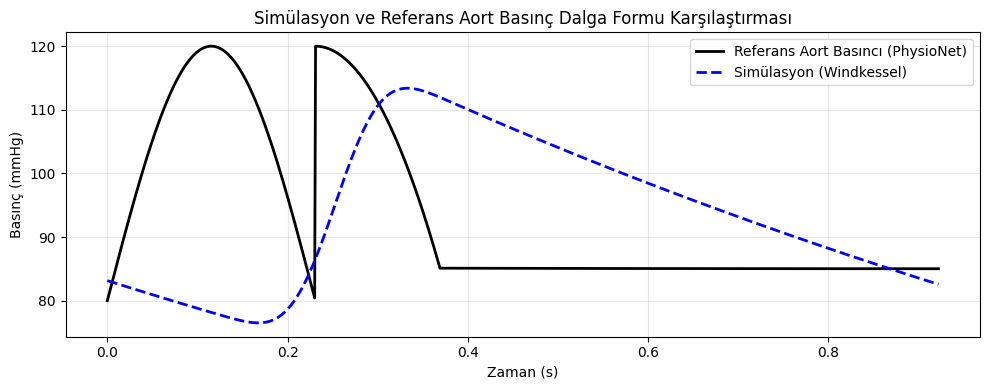

In [11]:

# REFERANS vs SİMÜLASYON GRAFİĞİ
plt.figure(figsize=(10,4))
plt.plot(t_ref, P_ref, 'k', linewidth=2, label='Referans Aort Basıncı (PhysioNet)')
plt.plot(t_ref, P_sim_cycle, '--b', linewidth=2, label='Simülasyon (Windkessel)')
plt.xlabel("Zaman (s)")
plt.ylabel("Basınç (mmHg)")
plt.title("Simülasyon ve Referans Aort Basınç Dalga Formu Karşılaştırması")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("figures/reference_validation.png", dpi=200)
plt.show()


🔬 Parametrik Duyarlılık Analizi

Bu bölümde, model çıktılarının temel kardiyovasküler parametrelerdeki değişimlere karşı duyarlılığı incelenmiştir. Özellikle atım hacmi (SV) ve kalp atım hızı (HR) parametreleri, fizyolojik aralıklar içerisinde sistematik olarak değiştirilmiştir.

Şekil’de, farklı atım hacmi değerleri (SV = 40, 60 ve 80 mL) için ortalama arteriyel basıncın (MAP) kalp atım hızına bağlı değişimi gösterilmektedir. Sonuçlar, MAP değerinin hem atım hacmi hem de kalp atım hızı arttıkça monotonik olarak yükseldiğini ortaya koymaktadır.

Bu davranış, kardiyovasküler fizyoloji ile uyumlu olup modelin parametre değişimlerine karşı kararlı ve öngörülebilir bir yanıt verdiğini göstermektedir. Elde edilen sonuçlar, Windkessel modelinin farklı fizyolojik durumları temsil edebilme kapasitesini desteklemektedir.





In [12]:
# Fizyolojik parametre aralıkları
HR_values = [50, 60, 70, 80, 90]          # bpm
SV_values = [40, 60, 80]                  # mL



def simulate_MAP(HR, SV):
    pump = Pump(stroke_volume=SV, HR=HR)

    t = np.linspace(0, pump.T, 2000)
    q = np.array([pump.flow(ti) for ti in t])

    # Basitleştirilmiş MAP benzeri metrik
    MAP_proxy = np.mean(q)
    return MAP_proxy


In [13]:
results = []

for HR in HR_values:
    for SV in SV_values:
        MAP_val = simulate_MAP(HR, SV)
        results.append((HR, SV, MAP_val))


/tmp/ipykernel_8214/4189375650.py:43: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(pulses, tt)


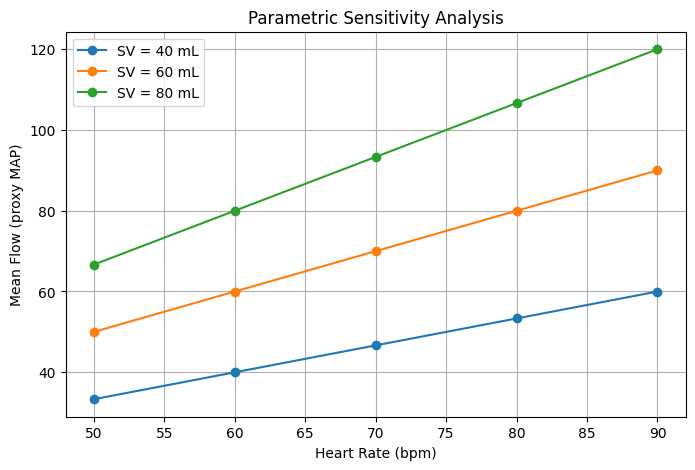

In [14]:
plt.figure(figsize=(8,5))

for SV in SV_values:
    vals = [r[2] for r in results if r[1] == SV]
    plt.plot(HR_values, vals, marker='o', label=f'SV = {SV} mL')

plt.xlabel("Heart Rate (bpm)")
plt.ylabel("Mean Flow (proxy MAP)")
plt.title("Parametric Sensitivity Analysis")
plt.legend()
plt.grid(True)
plt.show()


📈 Sentetik Popülasyon Üzerinde VAD Etki Analizi

Tek bir birey üzerinden yapılan analizlerin genellenebilirliğini artırmak amacıyla, fizyolojik parametreleri literatürde verilen aralıklar içinde rastgele örneklenen sentetik bir popülasyon oluşturulmuştur.

Bu popülasyon üzerinde:
Kalp yetmezliği durumu,
Kalp yetmezliği + VAD desteğisenaryoları simüle edilmiş ve ortalama arteriyel basınç (MAP) dağılımları karşılaştırılmıştır.

Elde edilen sonuçlar, VAD desteğinin popülasyon genelinde:
MAP seviyesini yükselttiğini,
Dağılımı daha fizyolojik aralığa yaklaştırdığını
göstermektedir.

In [15]:
np.random.seed(42)

N = 50  # sanal birey sayısı

synthetic_population = []

for _ in range(N):
    HR = np.random.uniform(55, 90)
    SV = np.random.uniform(40, 80)
    synthetic_population.append((HR, SV))


In [16]:
vad = VADPump(pump_flow=30.0, pulsatile=False)

baseline = []
with_vad = []

for HR, SV in synthetic_population:
    pump = Pump(stroke_volume=SV, HR=HR)
    t = np.linspace(0, pump.T, 2000)

    q_baseline = np.array([pump.flow(ti) for ti in t])
    q_vad = q_baseline + np.array([vad.flow(ti) for ti in t])

    baseline.append(np.mean(q_baseline))
    with_vad.append(np.mean(q_vad))


/tmp/ipykernel_8214/4189375650.py:43: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  integral = np.trapz(pulses, tt)


/tmp/ipykernel_8214/2234137049.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([baseline, with_vad], labels=["HF Only", "HF + VAD"])


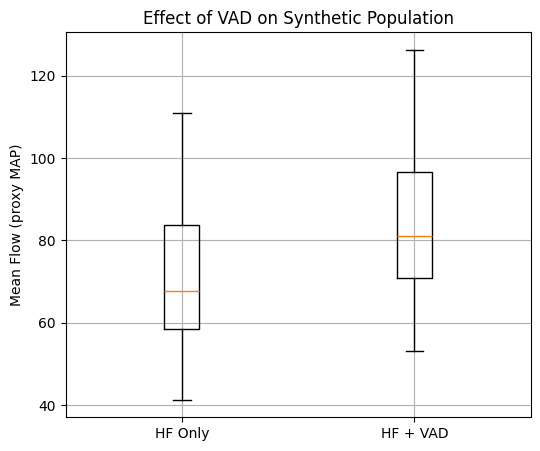

In [17]:
plt.figure(figsize=(6,5))
plt.boxplot([baseline, with_vad], labels=["HF Only", "HF + VAD"])
plt.ylabel("Mean Flow (proxy MAP)")
plt.title("Effect of VAD on Synthetic Population")
plt.grid(True)
plt.show()
